In [1]:
import torch
import torch.nn as nn
from torch.optim import SGD
import matplotlib.pyplot as plt #imports

In [2]:
x = [[1, 2], [3, 4], [5, 6], [7, 8]] #dados pro treino, onde y e a soma dos numeros nos pares
y = [[3], [7], [11], [15]]

In [3]:
X = torch.tensor(x).float()
Y = torch.tensor(y).float() #converte pra tensor

In [4]:
class MyNeuralNet(nn.Module): #classe
    def __init__(self): #funcao pra criar a rede
        super().__init__()
        self.layer1 = nn.Linear(2,8) #camada 1 de 2 input e 8 output
        self.activation = nn.ReLU() #funcao de ativacao
        self.layer2 = nn.Linear(8,1) #aq pega os 8 de saida da outra camada e coloca em uma saida

    def forward(self, x): #funcao q passa pras camadas
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

In [5]:
model = MyNeuralNet() #variavel da classe q tem as funcoes

In [6]:
loss_func = nn.MSELoss() #funcao de erro

In [8]:
opt = SGD(model.parameters(), lr = 0.001) #otimizador

In [10]:
losses = [] #lista pra perda
for _ in range(50): #50 epochs
    opt.zero_grad() #zera o gradiente pra nova epoca
    loss_value = loss_func(model(X),Y) #valor do erro
    loss_value.backward()

    opt.step() #atualiza os pesos
    losses.append(loss_value.detach().numpy()) #add na lista

Text(0, 0.5, 'loss value')

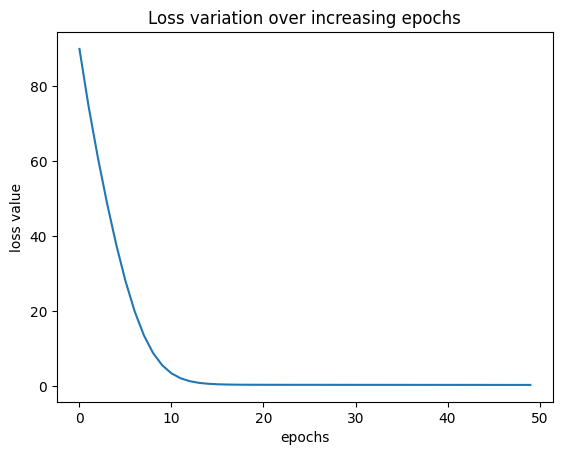

In [13]:
plt.plot(losses) #grafico
plt.title('Loss variation over increasing epochs') #titulo
plt.xlabel('epochs') #eixo x
plt.ylabel('loss value') #eixo y